In [1]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
from transformers import VideoMAEModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

NUM_FRAMES = 16
IMG_SIZE = 224
BATCH_SIZE = 2  # micro-batch for 16GB RTX 4060 Ti
GRAD_ACCUM_STEPS = 8  # effective batch size = 16
NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_MIN_EPOCHS = 25
EARLY_STOPPING_MIN_DELTA = 0.001
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

PROCESSED_ROOT = Path("processed/wlasl_top100")
TRAIN_META_PATH = PROCESSED_ROOT / "train_metadata.jsonl"
VAL_META_PATH = PROCESSED_ROOT / "val_metadata.jsonl"
LABELS_PATH = PROCESSED_ROOT / "labels_top100.json"

CHECKPOINT_DIR = Path("checkpoints/wlasl_top100")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT_PATH = CHECKPOINT_DIR / "best.pt"
LAST_CKPT_PATH = CHECKPOINT_DIR / "last.pt"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"Training device: {DEVICE}")
print(f"AMP enabled: {DEVICE.type == 'cuda'}")
print(f"Checkpoints: {CHECKPOINT_DIR}")

/mnt/linuxdata/CSCI4052-Course-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training device: cuda
AMP enabled: True
Checkpoints: checkpoints/wlasl_top100


In [2]:
def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


class NpyClipDataset(Dataset):
    def __init__(self, rows, transform=None):
        self.rows = rows
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        clip = np.load(row["clip_path"])  # (T, H, W, C)
        label = int(row["label_idx"])

        frames = []
        for t in range(clip.shape[0]):
            frame = clip[t]
            frame_tensor = self.transform(frame) if self.transform else torch.from_numpy(frame)
            frames.append(frame_tensor)

        clip_tensor = torch.stack(frames, dim=0)  # (T, C, H, W)
        return clip_tensor, label


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if not TRAIN_META_PATH.exists() or not VAL_META_PATH.exists():
    raise FileNotFoundError("Run preprocessing.ipynb first to create train/val metadata files.")
if not LABELS_PATH.exists():
    raise FileNotFoundError("Missing labels file. Run preprocessing.ipynb first.")

train_rows = load_jsonl(TRAIN_META_PATH)
val_rows = load_jsonl(VAL_META_PATH)

with LABELS_PATH.open("r", encoding="utf-8") as f:
    labels_obj = json.load(f)
labels = labels_obj["labels"] if isinstance(labels_obj, dict) and "labels" in labels_obj else labels_obj
NUM_CLASSES = len(labels)

train_dataset = NpyClipDataset(train_rows, transform=train_transform)
val_dataset = NpyClipDataset(val_rows, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Num classes: {NUM_CLASSES}")

Train samples: 7000
Val samples: 1500
Num classes: 100


In [3]:
class ASLVideoMAEClassifier(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.backbone = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
        hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def enable_gradient_checkpointing(self):
        self.backbone.gradient_checkpointing_enable()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # expected input: (B, T, C, H, W)
        outputs = self.backbone(pixel_values=x)
        features = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(features)


def topk_correct(logits: torch.Tensor, targets: torch.Tensor, k: int = 5) -> int:
    k = min(k, logits.shape[-1])
    _, pred = torch.topk(logits, k=k, dim=1)
    return pred.eq(targets.view(-1, 1)).any(dim=1).sum().item()


model = ASLVideoMAEClassifier(num_classes=NUM_CLASSES).to(DEVICE)
model.enable_gradient_checkpointing()
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_top5_accs, val_top5_accs = [], []
best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0


for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss = 0.0
    train_correct = 0
    train_top5_correct = 0
    train_total = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    for step, (frames, targets) in pbar:
        frames = frames.to(DEVICE, non_blocking=True).float()
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            logits = model(frames)
            loss = criterion(logits, targets) / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        train_loss += loss.item() * GRAD_ACCUM_STEPS
        preds = logits.argmax(dim=1)
        train_correct += (preds == targets).sum().item()
        train_top5_correct += topk_correct(logits, targets, k=5)
        train_total += targets.size(0)

        pbar.set_postfix(
            loss=train_loss / max(1, step + 1),
            acc=train_correct / max(1, train_total),
            top5=train_top5_correct / max(1, train_total),
        )

    if len(train_loader) % GRAD_ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    scheduler.step()

    epoch_train_loss = train_loss / max(1, len(train_loader))
    epoch_train_acc = train_correct / max(1, train_total)
    epoch_train_top5 = train_top5_correct / max(1, train_total)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_top5_correct = 0
    val_total = 0

    with torch.no_grad():
        for frames, targets in tqdm(val_loader, desc="Validation", leave=False):
            frames = frames.to(DEVICE, non_blocking=True).float()
            targets = targets.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
                logits = model(frames)
                loss = criterion(logits, targets)

            val_loss += loss.item()
            val_correct += (logits.argmax(dim=1) == targets).sum().item()
            val_top5_correct += topk_correct(logits, targets, k=5)
            val_total += targets.size(0)

    epoch_val_loss = val_loss / max(1, len(val_loader))
    epoch_val_acc = val_correct / max(1, val_total)
    epoch_val_top5 = val_top5_correct / max(1, val_total)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    train_top5_accs.append(epoch_train_top5)
    val_top5_accs.append(epoch_val_top5)

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "val_acc": epoch_val_acc,
            "val_top5_acc": epoch_val_top5,
            "labels": labels,
            "num_classes": NUM_CLASSES,
        },
        LAST_CKPT_PATH,
    )

    if epoch_val_acc > (best_val_acc + EARLY_STOPPING_MIN_DELTA):
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "best_val_acc": best_val_acc,
                "val_top5_acc": epoch_val_top5,
                "labels": labels,
                "num_classes": NUM_CLASSES,
            },
            BEST_CKPT_PATH,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Early-stop counter: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE} | "
        f"Best epoch: {best_epoch} | Best val acc: {best_val_acc:.4f}"
    )

    if (epoch + 1) >= EARLY_STOPPING_MIN_EPOCHS and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"No val_acc improvement greater than {EARLY_STOPPING_MIN_DELTA} for {EARLY_STOPPING_PATIENCE} epochs."
        )
        break

print(f"Training complete. Best val acc: {best_val_acc:.4f}")
print(f"Best checkpoint: {BEST_CKPT_PATH}")
print(f"Last checkpoint: {LAST_CKPT_PATH}")

Loading weights: 100%|██████████| 160/160 [00:00<00:00, 7588.67it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...11}.attention.attention.q_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 

Model parameters: 86,314,852


Epoch 1/100: 100%|██████████| 3500/3500 [06:37<00:00,  8.80it/s, acc=0.0261, loss=4.48, top5=0.101] 


Early-stop counter: 0/12 | Best epoch: 1 | Best val acc: 0.0407


Epoch 2/100: 100%|██████████| 3500/3500 [06:32<00:00,  8.91it/s, acc=0.0363, loss=4.32, top5=0.124]


...

Early-stop counter: 10/12 | Best epoch: 63 | Best val acc: 0.2300


Epoch 74/100: 100%|██████████| 3500/3500 [06:25<00:00,  9.08it/s, acc=0.937, loss=0.165, top5=1]


Early-stop counter: 11/12 | Best epoch: 63 | Best val acc: 0.2300


Epoch 75/100: 100%|██████████| 3500/3500 [06:25<00:00,  9.08it/s, acc=0.938, loss=0.16, top5=1] 


Early-stop counter: 12/12 | Best epoch: 63 | Best val acc: 0.2300
Early stopping at epoch 75. No val_acc improvement greater than 0.001 for 12 epochs.
Training complete. Best val acc: 0.2300
Best checkpoint: checkpoints/wlasl_top100/best.pt
Last checkpoint: checkpoints/wlasl_top100/last.pt


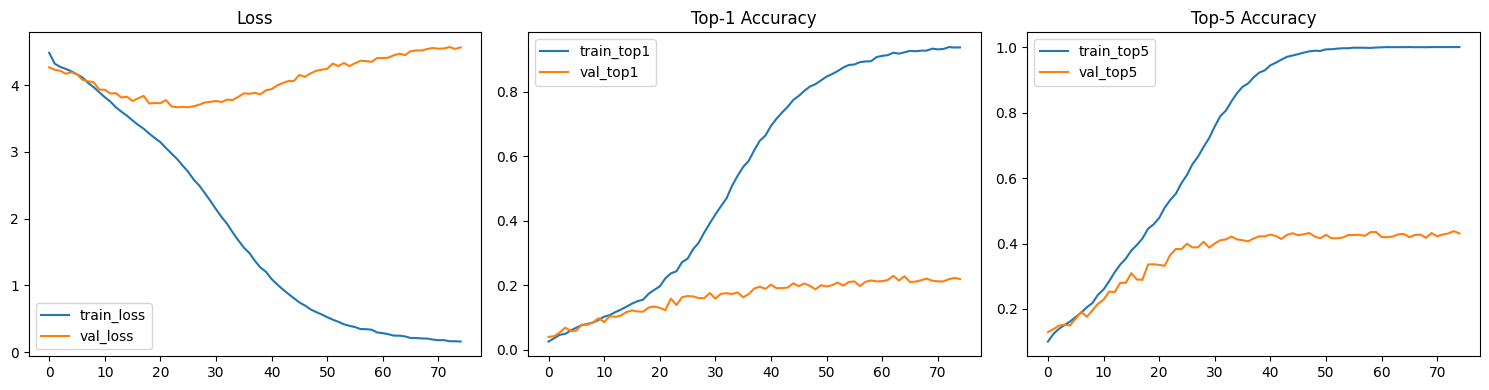

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_accs, label="train_top1")
plt.plot(val_accs, label="val_top1")
plt.title("Top-1 Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_top5_accs, label="train_top5")
plt.plot(val_top5_accs, label="val_top5")
plt.title("Top-5 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
# Top-k diagnostics on the validation set
import pandas as pd
import torch
from tqdm import tqdm

TOPK_TO_SHOW = min(20, NUM_CLASSES)  # set to NUM_CLASSES if you truly want all 100
SHOW_ROWS = 50
SAVE_CSV = True

# Load best checkpoint
best_state = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
if isinstance(best_state, dict) and "model_state_dict" in best_state:
    model.load_state_dict(best_state["model_state_dict"])
else:
    model.load_state_dict(best_state)
model.to(DEVICE).eval()

# Evaluate val set with top-k details
topk_hits = {k: 0 for k in range(1, TOPK_TO_SHOW + 1)}
total = 0
records = []
sample_ptr = 0

use_amp = DEVICE.type == "cuda"

with torch.no_grad():
    for frames, targets in tqdm(val_loader, desc="Collecting val top-k predictions"):
        frames = frames.to(DEVICE, non_blocking=True).float()
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
            logits = model(frames)
            probs = torch.softmax(logits.float(), dim=1)

        k = min(TOPK_TO_SHOW, probs.shape[1])
        top_vals, top_idxs = torch.topk(probs, k=k, dim=1)

        for i in range(frames.size(0)):
            true_idx = int(targets[i].item())
            pred_indices = top_idxs[i].tolist()
            pred_scores = top_vals[i].tolist()

            total += 1
            for kk in range(1, k + 1):
                if true_idx in pred_indices[:kk]:
                    topk_hits[kk] += 1

            row_meta = {}
            if hasattr(val_dataset, "rows") and sample_ptr < len(val_dataset.rows):
                row_meta = val_dataset.rows[sample_ptr]

            true_score = float(probs[i, true_idx].item())
            true_rank = int((probs[i] > probs[i, true_idx]).sum().item() + 1)

            rec = {
                "sample_global_idx": sample_ptr,
                "sample_id": row_meta.get("sample_id", sample_ptr),
                "clip_path": row_meta.get("clip_path", ""),
                "true_idx": true_idx,
                "true_label": labels[true_idx],
                "true_score": true_score,
                "true_rank": true_rank,
                "top1_idx": pred_indices[0],
                "top1_label": labels[pred_indices[0]],
                "top1_score": float(pred_scores[0]),
                "correct_top1": int(pred_indices[0] == true_idx),
            }

            for rank, (pidx, pscore) in enumerate(zip(pred_indices, pred_scores), start=1):
                rec[f"top{rank}_idx"] = int(pidx)
                rec[f"top{rank}_label"] = labels[int(pidx)]
                rec[f"top{rank}_score"] = float(pscore)

            records.append(rec)
            sample_ptr += 1

# Summaries
topk_summary = pd.DataFrame(
    [{"k": k, "topk_acc": topk_hits[k] / max(1, total)} for k in range(1, TOPK_TO_SHOW + 1)]
)

topk_summary["topk_acc_pct"] = (topk_summary["topk_acc"] * 100).round(2)

pred_df = pd.DataFrame(records)
pred_df = pred_df.sort_values(["correct_top1", "top1_score"], ascending=[True, False]).reset_index(drop=True)

print(f"Evaluated samples: {total}")
print(f"Best checkpoint used: {BEST_CKPT_PATH}")
display(topk_summary)

print("\nSample top-k predictions:")
display(pred_df.head(SHOW_ROWS))

print("\nHard mistakes (wrong top1 but high confidence):")
hard_cols = ["sample_id", "true_label", "top1_label", "top1_score", "true_score", "true_rank", "clip_path"]
display(pred_df[pred_df["correct_top1"] == 0][hard_cols].head(30))

if SAVE_CSV:
    out_csv = PROCESSED_ROOT / "val_topk_predictions.csv"
    pred_df.to_csv(out_csv, index=False)
    topk_summary.to_csv(PROCESSED_ROOT / "val_topk_summary.csv", index=False)
    print(f"\nSaved detailed predictions to: {out_csv}")
    print(f"Saved top-k summary to: {PROCESSED_ROOT / 'val_topk_summary.csv'}")

Evaluated samples: 1500
Best checkpoint used: checkpoints/wlasl_top100/best.pt


,k,topk_acc,topk_acc_pct
0,1,0.230000,23.00
1,2,0.315333,31.53
2,3,0.364000,36.40
3,4,0.397333,39.73
4,5,0.421333,42.13
5,6,0.452000,45.20
6,7,0.470667,47.07
7,8,0.487333,48.73
8,9,0.497333,49.73
9,10,0.514000,51.40



Sample top-k predictions:


,sample_global_idx,sample_id,clip_path,true_idx,true_label,true_score,true_rank,top1_idx,top1_label,top1_score,...,top17_score,top18_idx,top18_label,top18_score,top19_idx,top19_label,top19_score,top20_idx,top20_label,top20_score
0,117,5493,processed/wlasl_top100/clips/hearing/5493.npy,54,hearing,0.000480,2,55,kiss,0.998701,...,0.000011,43,woman,0.000009,25,thin,0.000007,53,hat,0.000006
1,627,37,processed/wlasl_top100/clips/book/37.npy,0,book,0.000002,82,34,like,0.993851,...,0.000078,53,hat,0.000066,61,tall,0.000063,67,bird,0.000063
2,913,903,processed/wlasl_top100/clips/bar/903.npy,9,bar,0.000149,6,8,backpack,0.990546,...,0.000025,62,white,0.000022,95,brown,0.000021,21,headache,0.000017
3,302,8074,processed/wlasl_top100/clips/last/8074.npy,80,last,0.000033,51,61,tall,0.988455,...,0.000137,81,meet,0.000116,31,cool,0.000113,60,study,0.000112
4,1226,8645,processed/wlasl_top100/clips/school/8645.npy,86,school,0.000038,45,6,wife,0.988392,...,0.000124,97,but,0.000120,78,forget,0.000115,3,visit,0.000107
5,898,2179,processed/wlasl_top100/clips/headache/2179.npy,21,headache,0.016270,2,22,inform,0.983262,...,0.000009,1,drink,0.000008,8,backpack,0.000008,57,later,0.000008
6,266,1548,processed/wlasl_top100/clips/cry/1548.npy,15,cry,0.002073,5,20,have,0.981563,...,0.000217,10,brother,0.000210,63,go,0.000194,8,backpack,0.000152
7,1040,3807,processed/wlasl_top100/clips/orange/3807.npy,38,orange,0.001001,7,92,africa,0.977892,...,0.000405,91,work,0.000403,67,bird,0.000345,82,pink,0.000338
8,160,1670,processed/wlasl_top100/clips/different/1670.npy,16,different,0.017756,2,17,door,0.977040,...,0.000099,84,play,0.000099,70,corn,0.000096,23,help,0.000093
9,963,6156,processed/wlasl_top100/clips/tall/6156.npy,61,tall,0.008097,2,59,shirt,0.977033,...,0.000215,36,mother,0.000212,75,doctor,0.000175,84,play,0.000169



Hard mistakes (wrong top1 but high confidence):


,sample_id,true_label,top1_label,top1_score,true_score,true_rank,clip_path
0,5493,hearing,kiss,0.998701,0.000480,2,processed/wlasl_top100/clips/hearing/5493.npy
1,37,book,like,0.993851,0.000002,82,processed/wlasl_top100/clips/book/37.npy
2,903,bar,backpack,0.990546,0.000149,6,processed/wlasl_top100/clips/bar/903.npy
3,8074,last,tall,0.988455,0.000033,51,processed/wlasl_top100/clips/last/8074.npy
4,8645,school,wife,0.988392,0.000038,45,processed/wlasl_top100/clips/school/8645.npy
5,2179,headache,inform,0.983262,0.016270,2,processed/wlasl_top100/clips/headache/2179.npy
6,1548,cry,have,0.981563,0.002073,5,processed/wlasl_top100/clips/cry/1548.npy
7,3807,orange,africa,0.977892,0.001001,7,processed/wlasl_top100/clips/orange/3807.npy
8,1670,different,door,0.977040,0.017756,2,processed/wlasl_top100/clips/different/1670.npy
9,6156,tall,shirt,0.977033,0.008097,2,processed/wlasl_top100/clips/tall/6156.npy



Saved detailed predictions to: processed/wlasl_top100/val_topk_predictions.csv
Saved top-k summary to: processed/wlasl_top100/val_topk_summary.csv


In [6]:
# Confusion analysis and hardest classes from validation predictions
import pandas as pd

if "pred_df" not in globals():
    raise RuntimeError("Run the previous top-k diagnostics cell first.")

mistakes_df = pred_df[pred_df["correct_top1"] == 0].copy()

confusion_pairs = (
    mistakes_df.groupby(["true_label", "top1_label"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

per_class_stats = (
    pred_df.groupby("true_label", as_index=False)
    .agg(
        samples=("true_label", "size"),
        top1_recall=("correct_top1", "mean"),
        avg_true_score=("true_score", "mean"),
        avg_true_rank=("true_rank", "mean"),
    )
    .sort_values("top1_recall", ascending=True)
)

per_class_stats["top1_recall_pct"] = (per_class_stats["top1_recall"] * 100).round(2)

print("Top confusion pairs (true -> predicted):")
display(confusion_pairs.head(30))

print("\nHardest classes by top-1 recall:")
display(per_class_stats.head(30))

print("\nEasiest classes by top-1 recall:")
display(per_class_stats.sort_values("top1_recall", ascending=False).head(20))

# Optional exports
confusion_pairs.to_csv(PROCESSED_ROOT / "val_confusion_pairs.csv", index=False)
per_class_stats.to_csv(PROCESSED_ROOT / "val_per_class_stats.csv", index=False)
print(f"\nSaved: {PROCESSED_ROOT / 'val_confusion_pairs.csv'}")
print(f"Saved: {PROCESSED_ROOT / 'val_per_class_stats.csv'}")

Top confusion pairs (true -> predicted):


,true_label,top1_label,count
534,headache,inform,6
360,different,door,6
241,check,class,4
524,hat,graduate,4
930,white,wrong,4
152,bowling,can,3
566,hot,yes,3
205,cat,brother,3
931,who,black,3
815,tall,shirt,3



Hardest classes by top-1 recall:


,true_label,samples,top1_recall,avg_true_score,avg_true_rank,top1_recall_pct
1,africa,15,0.000000,0.037323,31.600000,0.00
5,basketball,15,0.000000,0.045730,40.466667,0.00
12,book,15,0.000000,0.042891,29.866667,0.00
31,cow,15,0.000000,0.021149,42.266667,0.00
50,graduate,15,0.000000,0.016458,19.133333,0.00
46,fish,15,0.000000,0.009907,51.400000,0.00
41,eat,15,0.000000,0.033021,26.200000,0.00
37,doctor,15,0.000000,0.029128,33.733333,0.00
63,later,15,0.000000,0.038372,30.000000,0.00
34,dark,15,0.066667,0.055162,33.666667,6.67



Easiest classes by top-1 recall:


,true_label,samples,top1_recall,avg_true_score,avg_true_rank,top1_recall_pct
59,inform,15,1.000000,0.913115,1.000000,100.00
51,green,15,0.866667,0.809197,1.200000,86.67
52,hair,15,0.733333,0.734822,1.466667,73.33
19,cat,15,0.733333,0.681983,1.466667,73.33
32,cry,15,0.666667,0.613392,1.866667,66.67
25,class,15,0.666667,0.563472,3.133333,66.67
14,brother,15,0.666667,0.554789,7.200000,66.67
39,door,15,0.666667,0.638648,2.000000,66.67
54,have,15,0.600000,0.554249,2.000000,60.00
36,different,15,0.600000,0.568042,1.400000,60.00



Saved: processed/wlasl_top100/val_confusion_pairs.csv
Saved: processed/wlasl_top100/val_per_class_stats.csv
